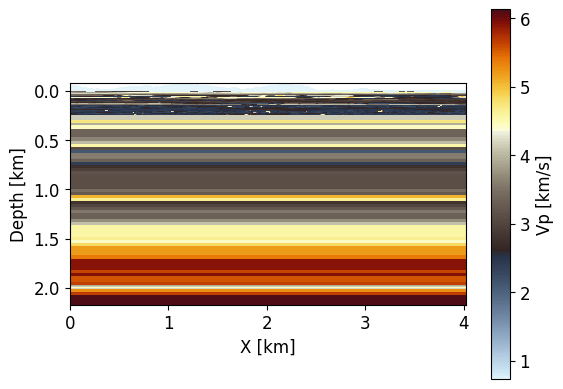

In [1]:
import numpy as np
import xarray as xr
from frequensolve import *
from pathlib import Path

project_path = "./scratch/ex_03/"

project = Project(
    name = "project",
    pretty_name = "Desert Simulation",
    path = project_path,
)

sim = project.new_simulation(
    name = "desert",
    physics = "elastic",
    dimension = 2,
    # f0 = 1.0,
)
project += sim

# --- Model ---
model = LayeredModel(
    dimension = 2, 
    x_limits = [0.0, 4.029],
)

model.add_surface(
    name = "dune_topo",
    z = "desert_data/dune_topo.nc",
    # z = -0.01,
    z_ref = 0.0,
)

model.add_layer(
    name = "sand",
    properties = { 
        "Vp" : 0.731, 
        "Vs" : 0.3,
        "Rho": 1.6,
        "Qp" : 50.0,# * PowerLawDispersion(f0 = 10.0, alpha = 0.9),
        "Qs" : 50.0,# * TablulatedDispersion([1.0, 10.0],[10.0, 20.0],extrapolation = "nearest"),
    }
)
                
model.add_surface(
    name = "buried_topo",
    z = "desert_data/buried_topo.nc",
    z_ref = 0.025,
)

model.add_layer(
    name = "near_surface",
    properties = { 
        "Vp" : "/Users/jacobbadger/hp3D/LIBS/problems/desert_2d/data/Vp_near.nc",
        "Vs" : "/Users/jacobbadger/hp3D/LIBS/problems/desert_2d/data/Vs_near.nc",
        "Rho": "/Users/jacobbadger/hp3D/LIBS/problems/desert_2d/data/Rho_near.nc",
        "Qp" : 100.0,
        "Qs" : 100.0,
    }
)

model.add_surface(z = 0.483e-1)
model.add_surface(z = 0.972e-1)
model.add_surface(z = 1.512e-1)
model.add_surface(z = 1.941e-1)
model.add_surface(z = 2.508e-1)

model.add_layer(
    name = "sub_surface",
    properties = { 
        "Vp" : "desert_data/Vp1D.nc",
        "Vs" : "desert_data/Vs1D.nc",
        "Rho": "desert_data/Rho1D.nc",
        "Qp" : 200.0,
        "Qs" : 200.0
    }
)

# Add lower surfaces
z_list = [ 3.9e-1, 4.791e-1, 5.712e-1, 6.312e-1, 6.99e-1, 
          7.551e-1, 9.981e-1, 1.059e0, 1.1211e0, 1.3032e0, 1.3662e0, 
          1.548e0, 1.7052e0, 1.8201e0, 1.881e0, 1.9692e0, 2.016e0,
          2.067e0, 2.1747e0 ]
for z in z_list:
    model.add_surface(z = z)

# sand = model.layers["sand"]
# grid = xr.DataArray(
#     dims = ["x", "z"], 
#     coords = {"x": np.linspace(0.0, 4.029, 501),
#               "z": np.linspace(-0.01, 0.2, 101)}
# )       
# sand.perturb(
#     property = ["Vs", "Vp", "Rho"],
#     std = 0.05,
#     L0 = 0.01,
#     nu = 0.5,
#     anisotropy = [1.0, 1.0],
#     xarr = grid,
#     seed = 12
# )

sim += model
model.plot(
    property = "Vp",
    aspect = "equal",
    surfaces = False,
    cmap = RdYlBu_r
)

# --- Mesh ---
mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh
sim.mesh.set_adapt(
    min_epw = {
        "x" : 1.5,
        "z" : 2.0,
    },
    f_adapt = 10.0,
    adapt_sources = 2,
    # jump_factor = 2.0,
    # jump_tolerance = 0.3,
    # f_low = 5.0,
    # f_med = 8.0
)

In [2]:
# --- Boundary Conditions ---

BCs = BoundaryConditionManager(label_type = "geometric")
BCs += BoundaryCondition(
    name = "free_surface",
    kind = "free",
    boundaries = ["z_min"]
)
BCs += BoundaryCondition(
    name = "pml",
    kind = "pml",
    boundaries = ["x_min", "x_max", "z_max"],
    pml_wavelengths = 0.3,
    pml_exponent = 3.0,
    pml_constant = 4.0
)
sim += BCs

# --- Acquisition ---

acq = Acquisition()

# Source
coords = [[4.023/2, 0.0]]
# coords = [ [x, 0.0] for x in np.linspace(0.0, 4.023, 1)]
acq.add_source_group(
    kind = "vector",
    coords = coords,
    direction = [0.0, 1.0],
    frame = "reference"
)
# acq.add_source_group(
#     kind = "scalar",
#     coords = [[4.023/2, 0.0]],
#     frame = "reference"
# )

# Receivers
device = ReceiverNode(name = "geophone")
device.add_component("u_z","displacement",[0.0, 1.0])
device.add_component("u_x","displacement",[1.0, 0.0])

coords = [ [x, 0.0] for x in np.linspace(0.0, 4.023, 1001)]
acq.add_receiver_group(
    name = "surface_geophones",
    device = device,
    coords = coords,
    frame = "reference",
    post_process = False,
)

coords = [ [x, 0.0] for x in np.linspace(0.0, 4.023, 1001)]
acq.add_receiver_group(
    name = "buried_geophones",
    device = device,
    coords = coords,
    post_process = False,
)
sim += acq

# --- Discretization ---

method = Discretization(
    order = {
        "x" : 4,
        "z" : 4,
    },
)
sim += method

# --- Solver Options ---

solver = SolverConfig(
    max_iter = 100,
    grids = 2,
    tolerance = 1.e-4
)
sim += solver

# --- Outputs ---

out = OutputManager()
out += ParaviewOutput(
    name = "desert", 
    fields = ["displacement", "pressure"], 
    upscale = 1,
    post_process = False,
)
sim += out

project.save()

PosixPath('/Users/jacobbadger/omnirepo/FrequenSolve/examples/scratch/ex_03/project.json')

0.21721172526635651


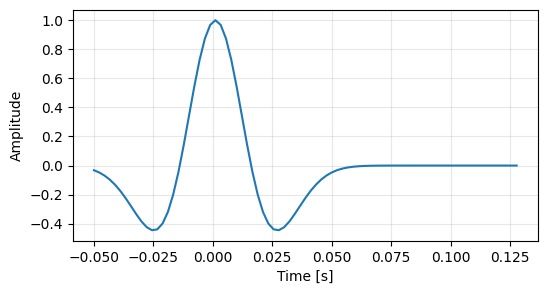

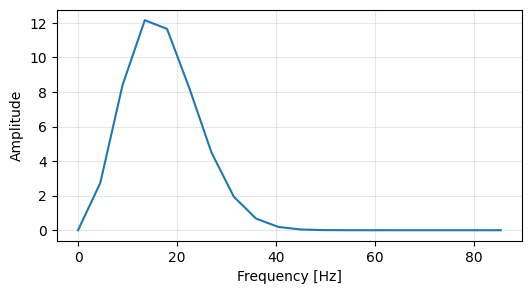

KeyError: "Group 'buried_geophones' not found in HDF5 /Users/jacobbadger/omnirepo/FrequenSolve/examples/scratch/ex_03/jobs/desert/job/results/receivers/receivers_1.h5"

: 

In [ ]:
# --- Connect to site ---
   
site = "local"

site = LocalSite(n_workers = 8)
site.sync(project)

T_max = 3.0
s = np.log(60)/(2*np.pi*T_max)
print(s)

job = TimeDomainJob(
    name = "job",
    simulation = sim,
    s_laplace = -s,
    f_min = 1.0,
    f_max = 50.0,
    T_max = T_max
)
# job = FrequencyDomainJob(
#     name = "fd_job",
#     simulation = sim,
#     f_list = [100.0],
# )

# site.submit(job)

wavelet = RickerWavelet(
    f = 15.0,
    center = 1.0/20.0
)
# wavelet = KlauderWavelet(
#     f = [20.0, 40.0],
#     window = ("blackman", 0.06),
#     center = 0.03
# )
wavelet.plot(T_max = 0.18,f_max = 90.0)

trace_db = site.fetch_traces(job, upscale = 4)

print(trace_db)
for group in trace_db.groups:
    for shot in trace_db.shots(group):
        for comp in trace_db.components(group):
            td = trace_db.read_TD(group, comp, shot, wavelet, upscale = 4)
            plt.figure(figsize=(8, 6))
            plot = td.plot(
                vmin = -.025, 
                vmax = .025, 
                y = "time", 
                yincrease = False,
                cmap = "gray"
            )

            exp = xr.DataArray(
                np.exp(2*np.pi*s*td.coords["time"]),
                dims = ["time"],
                coords = {"time": td.coords["time"]},
            )
            td *= exp

            plt.show()